In [ ]:
import torch
import numpy as np

#### 1. Tenser 基础

tensor 张量的定义

In [ ]:
x = torch.empty(5, 3) # 生成一个 5×3 的空矩阵
# print(x)

x = torch.rand(5, 3) # 生成一个 5×3 的随机参数矩阵（均匀分布） torch.randn(5, 3)为标准正态分布
# print(x)

x = torch.arange(6) # 生成一个 0 到 5 的一维数组 torch.arange(x, y)生成的是x到y-1的数
# print(x)

x = torch.zeros(5, 3) # 生成一个 5×3 的全零矩阵，可以用x = torch.zeros(5, 3, dtype = torch.long)指定类型
# print(x)

x = torch.tensor([5.5, 3]) # 直接创建矩阵 tensor([5.5000, 3.0000])
# print(x)

x = torch.tensor([[1, 2, 3], [4, 5, 6]]) # 直接创建矩阵 tensor([[1, 2, 3],
                                                             # [4, 5, 6]]) 注意其中的双层中括号
# print(x)

example = np.array([[1, 2], [3, 4]])
x = torch.tensor(example) # 可以直接从numpy数组中进行导入
# print(x)

x = torch.from_numpy(example) # 用torch.from_numpy(*)方法会让torch张量和numpy数组共享空间
example[0, 0] = 5 #修改numpy数组第一个位置为 5 之后，张量也会改变 tensor([[5, 2],
# print(x)                                                            [3, 4]])

x = torch.ones(5, 3) # 生成一个 5×3 的全1矩阵
# print(x)

x = torch.eye(5, 3) # 生成对应大小的对角矩阵，如果非方阵就填满其行列相等的位置
# print(x)

Tensor 张量的操作

In [ ]:
x = torch.tensor([[1, 2, 3],[4, 5, 6],[7, 8, 9]])

shape = x.shape # 查看 tensor 的形状，查看本身属性，shape后无括号，x.shape[0]是行数，x.shape[1]是列数
# print(shape) 
dim = x.ndim # 查看 tensor 的维度，查看维度信息，ndim后无括号
# print(dim)
number = x.numel() # 查看 tensor 的元素总数 
# print(number)

x = torch.arange(1, 10)

x = x.reshape(3, 3) # 将 tenser 转化成 3×3 大小，这里的大小有限制
# print(x)

x = x.reshape(3, -1) # -1 表示会自动计算维度，得到的是 3×3 的张量，reshape(-1)表示展平
# print(x)

x = x.unsqueeze(0) # 将张量添加一个维度，(3,3)->(1,3,3)，其中unsqueeze(*)中的*代表在第*个位置增加维度
# print(x)

x = x.squeeze(0) # 将张量去掉一个维度，(1,3,3)->(3,3)，squeeze(*)的含义同上
# print(x)

x = x.transpose(0,1) # 将维度进行交换，在二维条件下相当于转置
# print(x)

y = torch.randn(2,3,4) 

y = y.permute(2,0,1) # 交换维度的位置 (2,3,4)->(4,2,3)
# print(y)

y = y.flatten(start_dim=1) # 进行展平操作，(4,2,3)->(4,6)，可以指定start_dim，end_dim
# print(y)

y = torch.randn(2,3,4) 

y = y.view(1, -1) # view(*shape) 得到 torch.Size([1, 24])，其中 1 是人为设置的分量，-1 代表自动计算维度
# print(y.shape)

对多个 Tensor 张量进行操作

In [ ]:
a = torch.randn(2, 3)
b = torch.randn(2, 4)

cat = torch.cat([a, b], dim = 1) # dim=1 是横向拼接，要求列维度相同；dim=0 是纵向拼接，要求行维度相同
# print(cat)

c = torch.randn(2, 3)

stack = torch.stack([a, c], dim = 0) # stack 的两个张量的形状必须一致
# print(stack.shape)  # stack 的本质是选择一个维度dim，沿着dim维度将两个张量叠起来，dim为负代表在最后一维之后堆叠

对 Tensor 张量的索引

In [ ]:
x = torch.arange(12).reshape(3, 4)

print(x[1,2]) # 通过索引直接返回第2行第3列的值

print(x[0:2, 1:3]) # 返回第1、2行，第2、3列；注意其中是左闭右开 
# x[:,*:*]是取所有行，x[*:*,:]是取所有列

张量的计算

In [ ]:
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])

plus = a + b # 张量的按位加法
# print(plus)

minus = b - a # 张量的按位减法
# print(minus)

times = a * b # 张量的按位乘法
# print(times)

square = a ** 2 # 张量把其中的每一个位置乘方 
# print(square)

# 其余的除法、取余等都是类似的

在很多时候我们可以运用张量运算对数据进行矢量化加速，相比于通过循环进行按位加法，直接加减张量会更加快速。同时代码更加简洁，还可以兼容自动微分

In [ ]:
a = torch.randn(3, 4)
b = torch.randn(4, 2)

times = a @ b # 矩阵的乘法，必须满足矩阵乘法的要求
# print(times)

sum = a.sum() # 对a中的所有元素进行求和
# print(sum)

sum = a.sum(dim = 1) # 对a中的每一列元素进行求和 tensor([*, *, *])是一维的
# print(sum)

sum = a.sum(dim = 1, keepdim = True) # keepdim表示保留原有的维度 tensor([[*], [*], [*]])是2维的
# print(sum)

mean = a.mean() # 对a中所有元素取平均值
# print(mean)

mean = a.mean(dim = 1, keepdim = True) # 对列求平均值并且保留维度
# print(mean)

max_val = a.max() # 求全局的最大值
# print(max_val)

max_val, max_idx = a.max(dim = 1) # 按列求最大值，可以返回对应的索引
# print(max_val, max_idx)

# min是最小值，和max方法的语法一致

max_idx = a.argmax() # 求全局最大值的索引 tensor(*)，代表的是展平后的第*个位置
# print(max_idx)

max_idx = a.argmax(dim = 1) # 对每列求最大值，并且返回最大值的索引
# print(max_idx)

a = torch.clamp(a, max = 1, min = 0) # 对 Tensor 进行截断，给定最小值和最大值
# print(a)

两个张量之间的点积

In [ ]:
# 如果要计算 a, b 的点积，有一下几种方式
a = torch.randn(3)
b = torch.randn(3)

dot = a.T @ b # 利用矩阵乘法

dot = torch.dot(a, b) # 调用 torch 中的 dot 方法

dot = torch.sum(a * b) # 按位乘法后进行求和

# print(dot)

求范数

In [ ]:
# L_1 范数是向量中每个元素绝对值的和，L_2 范数是向量中每个元素的平方和再开根号

u = torch.tensor([1.0, 2.0, 3.0]) # 注意：所用的 tensor 必须是 float，否则会报错

L_1 = torch.abs(u).sum() # 用 torch.norm(u, p=1) 也可以

L_2 = torch.norm(u) 

print(L_1, L_2)

追踪对torch张量进行的操作

In [ ]:
example = torch.ones(2, 2, requires_grad=True)

example = example + 2

print(example.grad_fn) # 追踪向量有 gard_fn 属性

example = example ** 2

print(example.grad_fn)

In [ ]:
# 事实上我们可以对 torch 文件中的内容进行查询，如：

In [ ]:
print(dir(torch.distributions)) # 查询 torch 自带的概率分布

#### 2. 自动求导 auto_gard

In [ ]:
x = torch.tensor([2.0,3.0], requires_grad = True) # 注意只有数据类型有浮点数才可以追踪梯度

y = x**2 + 2*x + 1 

sum = y.sum()

sum.backward()

# print(x.grad) # tensor([6., 8.])

x.grad.zero_() # 梯度清零，梯度会在每次 backwards 时不断累加，所以要进行梯度清零

# 如果输出的是向量或张量，需要自定义一个 gard_tensor，这个 tensor 相当于求导后乘上的权重

z = x**2 + 2*x + 1 # 注：同一个计算图不能重复利用，因为在计算时会自动释放中间步骤的空间

z.backward(gradient=torch.tensor([1.0,0.5])) # 相当于 (2*x+2)*tensor([1.0,0.5]) 

# print(x.grad)

#### 3. 神经网络 torch.nn 基础

In [ ]:
import torch.nn as nn 
import torch.nn.functional as F

神经网络类模板

In [ ]:
class Net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Net, self).__init__() # 需要调用父类进行初始化

        # 定义神经网络结构

        self.fc_1 = nn.Linear(input_dim, hidden_dim) # Network*(输入维度，输出维度)
        self.relu = nn.ReLU()
        self.fc_2 = nn.Linear(hidden_dim, output_dim)

    # 需要重载 forward 函数，反向传播由 autogard 自动完成

    def forward(self, x):
        out = self.fc_1(x)
        out = self.relu(out)
        out = self.fc_2(out)
        return out
    
model = Net(input_dim=10, hidden_dim=64, output_dim=2) # 实例化一个模型

print(model) # 可以直接对模型结构进行打印

# print(list(model.parameters())) # 查看模型中的所有可训练参数

# print(model.named_parameters()) # 查看模型中的参数名和参数值，依旧可以用 list 查看具体内容

torch.nn 中的神经网络层结构

In [ ]:
# 全连接层（输入维度，输出维度，是否加偏置项）
fc = nn.Linear(in_features=10, out_features=64, bias=True) 

# 2d卷积层（输入通道数，输出通道数，卷积核大小，步长，padding大小）
fc = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)

# 2d池化层（池化核大小，步长）
fc = nn.MaxPool2d(kernel_size=2, stride=2) 
fc = nn.AvgPool2d(kernel_size=2, stride=2)

# 批归一化层（输入维度）
fc = nn.BatchNorm2d(num_features=10)

# Dropout层（随机丢弃概率）
fc = nn.Dropout(p=0.5)

# LSTM层（输入维度，隐藏层维度，层数，是否batch维度在前）
fc = nn.LSTM(input_size=128, hidden_size=64, num_layers=2, batch_first=False)

torch.nn 和 torch.nn.functional中的激活函数

In [ ]:
# relu 函数，inplace 代表不新开内存，一般默认为 false
relu = nn.ReLU(inplace=False)  # relu = F.relu(x)

# sigmoid 函数
sigm = nn.Sigmoid() # sigm = F.sigmoid(x)

# softmax 函数
softmax = nn.Softmax(dim=1) # softmax = F.softmax(x, dim=1)

# Tanh 函数
tanh = nn.Tanh() # tanh = F.tanh(x)

神经网络的训练与评估

In [ ]:
model.train() # 训练模式，在这一模式下 model 可以进行参数更新

model.eval() # 评估模式，在这一模式下 model 不再进行 Dropout，需要依靠 torch.no_grad()关闭梯度计算

张量在神经网络训练过程中形状的流动

In [ ]:
# 用一个简单的卷积神经网络看张量维度的流动
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # 神经网络的层
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.fc1 = nn.Linear(32*8*8, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)
 
    # 前向传播算法
    def forward(self, x):
        # x: [batch, 3, 32, 32]
        x = self.pool(torch.relu(self.bn1(self.conv1(x)))) # [batch, 3, 32, 32]->[batch, 16, 16, 16]
        x = self.pool(torch.relu(self.bn2(self.conv2(x)))) # [batch, 16, 16, 16]->[batch, 32, 8, 8]
        x = x.view(-1, 32*8*8) # [batch, 32*8*8]
        x = self.fc2(self.dropout(torch.relu(self.fc1(x)))) # [batch, 32*8*8]->[batch, 128]->[batch,10]
        return x 

model = CNN()
# print(model)
test = torch.randn(4, 3, 32, 32)

result = model.forward(test) # 进行前向传播

print(result.shape)

含分支的神经网络结构

In [ ]:
class DuelingDQN(nn.Module): # 以强化学习中的 Dueling DQN 为例，展示如何构建一个具有分支结构的神经网络
    def __init__(self, input_dim, hidden_dim, output_dim): # 神经网络初始化时也可以传入参数
        super(DuelingDQN, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.value_fc = nn.Linear(hidden_dim, 1) 
        self.advantage_fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.relu(self.fc1(x))  # [batch, 10]->[batch, 64]
        value = self.value_fc(x)         # 价值函数分支 [batch, 64]->[batch, 1]
        advantage = self.advantage_fc(x) # 优势函数分支 [batch, 64]->[batch, 4]
        q_values = value + (advantage - advantage.mean(dim=1, keepdim=True)) # [batch, 4] 广播机制
        return q_values

model = DuelingDQN(input_dim=10, hidden_dim=64, output_dim=4)
# print(model)
test = torch.randn(4, 10)

print(model.forward(test).shape)

模型的训练

In [ ]:
# 以上面的 Dueling DQN 为例，展示如何进行模型的训练和评估(运行前先运行上面的代码段)

model = DuelingDQN(input_dim=10, hidden_dim=64, output_dim=4) # 定义神经网络模型

criterion = nn.MSELoss() # 定义损失函数

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # 定义优化器

test_tensor = torch.randn(4,10) 

for epoch in range(100): # 代表 100 轮训练

    model.train()

    optimizer.zero_grad() # 梯度清零

    outputs = model(test_tensor) # 前向传播

    target = torch.randn(4,4) # 生成一个随机的目标张量 (实际训练中计算TD误差)

    loss = criterion(outputs, target) # 计算损失

    loss.backward() # 反向传播

    optimizer.step() # 更新参数

    # print(f'Epoch {epoch+1}, Loss: {loss.item()}') # 打印每轮的损失值

优化器

In [ ]:
import torch.optim as optim

# 带动量的随机梯度下降优化器
optimizer = optim.SGD(model.parameters(), lr = 0.01, momentum=0.9) 

# Adam 优化器，含权重衰减 (L2正则化)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5) 

# 一个进阶版 Adam 优化器 (改进权重衰减)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

# 其中的 parameters() 方法会返回模型中所有可训练的参数

optimizer.zero_grad() # 代表每次循环中重新计算梯度，否则梯度累计

#### 4. 线性回归

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn

随机梯度下降法：
$$\theta := \theta-\alpha \sum_{i}\nabla _\theta J^{(i)}(\theta)\quad \text{梯度下降}$$
$$\theta := \theta-\frac{\alpha}{|\mathcal{B}|} \sum_{i\in \mathcal{B}}\nabla _\theta J^{(i)}(\theta)\quad \text{随机梯度下降}$$

我们先给出一个自己实现的线性回归模型

In [ ]:
# 初始化参数
w = torch.randn(3, 1, requires_grad=True) # [features, 1] = [3, 1]
b = torch.zeros(1, requires_grad=True) # [1]
# print(w, b)

In [ ]:
# 定义线性函数
def linreg(X, w, b): 
    
    return X @ w + b # [batch, features] @ [features, 1] + [1] = [batch, 1]

# 定义损失函数
def squared_loss(y_pred, y_true):

    return torch.mean((y_pred - y_true) ** 2)

# 一个简单的 SGD 优化算法
def sgd(params, lr, batch_size): # params 是列表，代表可优化参数；lr 是学习率；batch_size 是批量数

    with torch.no_grad(): # 代表在这个代码块中不需要计算梯度，不被 autograd 追踪

        for param in params:

            param -= lr * param.grad / batch_size

            param.grad.zero_()

数据集的生成和读取

In [ ]:
def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1, (num_examples, len(w))) # [batch, features] 

    y = X @ w + b + torch.normal(0, 0.01, (num_examples, 1)) 

    return X, y.reshape(-1, 1) # y.reshape->[batch, 1]  

true_b, true_w = 4.2, torch.tensor([2.0, 3.0, -4.0])

features, labels = synthetic_data(true_w, true_b, 1000) 

In [ ]:
def load_data(batch_size, features, labels):
    num_examples = len(features)

    indices = list(range(num_examples))

    np.random.shuffle(indices) # 随机打乱索引顺序

    for i in range(0, num_examples, batch_size):

        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])

        yield features[batch_indices], labels[batch_indices] 

batch_size = 10

for X, y in load_data(batch_size, features, labels):
    print(X, '\n', y)
    break

训练过程

In [ ]:
epochs = 5
lr = 0.03
for epoch in range(epochs):

    for X, y in load_data(batch_size, features, labels): # 批量读取 data

        y_pred = linreg(X, w, b)

        loss = squared_loss(y_pred, y)

        loss.backward()
        
        sgd([w, b], lr, batch_size) # sgd 优化参数

print(true_w - w.reshape(true_w.shape), true_b - b)

线性回归的简化版书写

In [ ]:
import numpy as np
import torch
from torch.utils import data
from torch import nn

In [ ]:
# 创建模拟数据集
true_w = torch.tensor([2.0, 3.0, -4.0])
true_b = 4.2

features, labels = synthetic_data(true_w, true_b, 1000)

In [ ]:
# 构建一个数据集加载器
def load_array(data_arrays, batch_size, is_train=True):

    dataset = data.TensorDataset(*data_arrays) # 将数据封装成 TensorDataset 对象
    
    return data.DataLoader(dataset, batch_size, shuffle=is_train) 

# 会返回一个 data.DataLoader 对象，shuffle=True 代表在训练模式下会打乱数据顺序

batch_size = 10
data_iter = load_array((features, labels), batch_size)

In [ ]:
# 线性回归相当于是一个单独的线性层，所以我们可以直接用 nn.Linear 来构建一个线性回归模型

net = nn.Linear(3, 1)  # net = sequential(nn.Linear(3, 1)), sequential 是一个容器，可以把多个层组合在一起

loss = nn.MSELoss() # 定义损失函数

trainer = torch.optim.SGD(net.parameters(), lr=0.03) # 定义优化器

epochs = 5
for epoch in range(epochs):
    for X, y in load_data(batch_size, features, labels): # 批量读取 data

        los = loss(net(X), y) 

        trainer.zero_grad() 

        los.backward()

        trainer.step() 

w = net.weight.data

b = net.bias.data

print(true_w - w.reshape(true_w.shape), true_b - b)

#### 5. Softmax 回归

In [ ]:
# softmax 回归主要用于分类任务，让每一个分类对应一个输出值。

# 对于一个有 4 个 feature ，3 个类别的任务，对应一个有三个神经元的输出层，和四个神经元的输入层。在输出时，我们对其进行softmax处理，选择 softmax 的最大值作为所预测的类别。

In [ ]:
import torch 
import torch.nn as nn
import torchvision

In [ ]:
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

loss = nn.CrossEntropyLoss(reduction = 'none') # 交叉熵损失，reduction 意义见下

trainer = torch.optim.SGD(net.parameters(), lr=0.1)


关于损失函数的 reduction

In [ ]:
y_pred = torch.tensor([[1.0], [3.0], [4.0]]) # 两个样本在三个类别上的预测值
y_true = torch.tensor([[0.0], [3.0], [2.0]]) 

mse = nn.MSELoss()
# print(mse(y_pred, y_true)) # tensor(1.6667) 默认的均方误差值

mse = nn.MSELoss(reduction = 'sum') # reduction='sum' 代表求和，不求平均
# print(mse(y_pred, y_true)) # tensor(5.)

mse = nn.MSELoss(reduction = 'none') # reduction='none' 代表不进行任何操作，直接返回每个元素的损失值
# print(mse(y_pred, y_true)) # tensor([[1.], [0.], [4.]])

mse = nn.MSELoss(reduction = 'mean') # reduction='mean' 代表求平均值，同默认

In [ ]:
logits = torch.tensor([
    [1.2, 0.5, -0.3, 2.1, 0.8, -1.0, 0.7, 1.5, -0.8, 0.2],  
    [0.3, -0.2, 1.8, 0.7, -1.1, 2.5, 0.9, -0.5, 1.0, 0.1],  
    [-0.5, 1.9, 0.4, -1.2, 0.6, 0.8, 2.2, -0.7, 1.1, 0.3]  
]) # [batch, num_classes]
labels = torch.tensor([3, 5, 6]) # [batch] 实际我们也将其表示成 one-hot 编码的形式

cross = nn.CrossEntropyLoss()
# print(cross(logits, labels)) # tensor(1.0298) 交叉熵平均损失

cross = nn.CrossEntropyLoss(reduction = 'none')
# print(cross(logits, labels)) # tensor([1.1042, 0.8890, 1.0962]) 交叉熵每个样本的损失值

cross = nn.CrossEntropyLoss(reduction = 'sum') 
# print(cross(logits, labels)) # tensor(3.0894) 交叉熵总损失

cross = nn.CrossEntropyLoss(reduction = 'mean')
# print(cross(logits, labels)) # tensor(1.0298) 交叉熵平均损失，同默认

#### 6. 多层感知机

In [ ]:
# Q&A：隐藏层的作用是什么：单一的线性层只能够拟合线性关系，而事实上许多任务并不是线性的，所以需要隐藏层。理论上，多层感知机能够拟合任意的函数

In [ ]:
# 构建一个多层感知机
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))

In [ ]:
# 事实上，神经网络的层数越多越复杂，会增加过拟合的风险，为降低过拟合，我们可以使用正则化方法，如权重衰减

L2 正则化

In [ ]:
net = nn.Sequential(nn.Linear(784, 10))

loss = nn.CrossEntropyLoss(reduction = 'none')

optimizer = torch.optim.SGD([{'params': net[0].weight, 'weight_decay': wd}, 
                             {'params': net[0].bias}], lr=0.1)

In [ ]:
# 值得注意的是，我们常用的 Adam 优化器，在进行权重衰减时，效果可能并不好，AdamW 优化器是一个改进版的 Adam 优化器，能够更好地处理权重衰减问题。
# 因此在需要进行权重衰减时，建议使用 AdamW 优化器，代替 Adam 优化器。

Dropout 方法

In [ ]:
# dropout 即在反向传播时随机地让一些神经元失效，降低过拟合风险。

# Q&A：为什么 dropout 能够降低过拟合风险。这是因为在训练时，dropout 随机令若干神经元失效，强行增加了模型训练的多样性，不让其过于依赖某些特征。

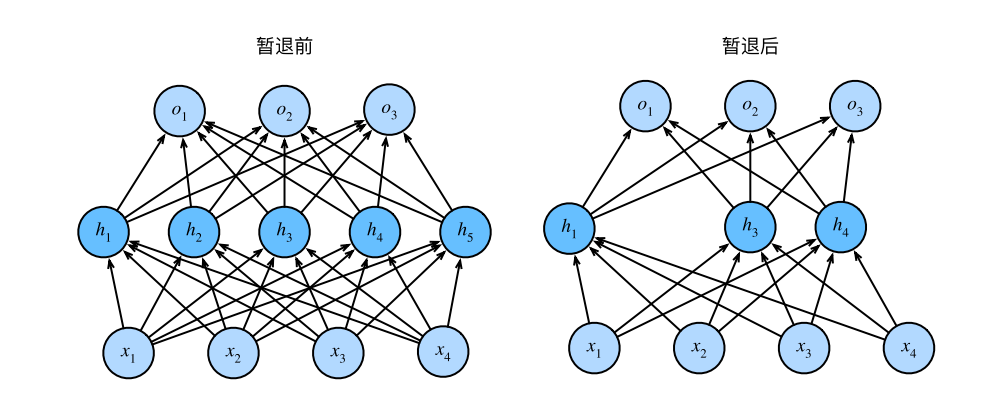

In [ ]:
# 含 dropout 的多层感知机
dropout_1, dropout_2 = 0.2, 0.5

class net(nn.Module):
    def __init__(self, num_inputs = 784, num_outputs = 10, num_hiddens1 = 256, num_hiddens2 = 256):
        super(net, self).__init__()
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)   
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.dropout1 = nn.Dropout(dropout_1)
        self.dropout2 = nn.Dropout(dropout_2)
        self.relu = nn.ReLU()

    def forward(self, X):
        X = self.relu(self.lin1(X))
        X = self.dropout1(X)
        X = self.relu(self.lin2(X))
        X = self.dropout2(X)
        return self.lin3(X)

model = net() # 默认是训练模式，训练模式自动启用 dropout

model = model.eval() # 将模型切换到评估模式，评估模式自动关闭 dropout

#### 7. 代码模块的组合

In [ ]:
# 神经网络的多个层可以组合成块，不同块之间可以结合起来成为更大的模型；块即我们实现的神经网络类，以下是若干种模块的实现方式

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
# 一个自定义块就是我们自己定义的神经网络类 如上个代码块的 class net

# nn.Sequential 是一个顺序块，可以组合代码块

model = nn.Sequential(net(), nn.Flatten()) # 可以调用我们上面定义过的 net 类


前向传播中集成的函数

In [ ]:
# 我们可以自行编写 forward 函数
class FixedHiddenMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.rand_weight = torch.rand((20, 20), requires_grad=False) 

        self.lin = nn.Linear(20, 20)
    
    def forward(self, X):
        
        X = self.lin(X)

        X = F.relu(torch.mm(X, self.rand_weight)+1) # 人为实现一个隐藏层逻辑，反向传播时不会更新这一层的参数，权重是 rand_weight；torch.mm 表示矩阵乘积

        X = self.lin(X) # 这两层运用了相同的 linear 层，这说明它们共用同一个参数

        while X.abs().sum() > 1: # 如果 L1 范数大于 1 就除以 2 直至满足要求
            X /= 2

        return X.sum()
    
model = FixedHiddenMLP()

X = torch.randn(20, 20)

print(model(X))

嵌套块

In [ ]:
class NestMLP(nn.Module):
    def __init__(self):
        super().__init__()

        # 一个嵌套式的神经网络块
        self.net = nn.Sequential(nn.Linear(20, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU())

        self.linear = nn.Linear(32, 16)

    def forward(self, X):

        return self.linear(self.net(X))

# 可以将这些网络块全部都组合起来
allmodel = nn.Sequential(NestMLP(), nn.Linear(16, 20), FixedHiddenMLP())

# print(allmodel(X))


参数管理

In [ ]:
# 我们可以直接通过模型访问参数，Sequential 可以直接通过索引访问模型参数

# print(allmodel[1].state_dict())

print(allmodel[1].bias) # bias 本质上是一个参数类实例

print(allmodel[1].bias.data) # bias.data 是具体的数值

#### 8. 卷积神经网络及衍生算法

互相关运算（卷积）的实现

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# 进行一个二维的互相关运算，即我们熟知的卷积操作，其中 X 是输入矩阵，K 是卷积核
def corr2d(X, K):
    
    height, width = K.shape

    Y = torch.zeros((X.shape[0]-height+1, X.shape[1]-width+1))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+height, j:j+width]*K).sum()

    return Y

# X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
# K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])

# print(corr2d(X, K)) # tensor([[19., 25.],
                      #        [37., 43.]])

卷积层

In [ ]:
class conv2d(nn.Module):
    def __init__(self, kernal_size):
        super().__init__()

        self.weight = nn.Parameter(torch.rand(kernal_size))

        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return corr2d(x, self.weight) + self.bias

卷积层训练的实现

In [ ]:
# 所谓训练卷积层其实就是训练卷积核的参数
conv2d = nn.Conv2d(1, 1, kernel_size=(1, 2), bias=False)

X = torch.ones((6, 8))
X[:, 2:6] = 0
# print(X)

K = torch.tensor([[1.0, -1.0]])

Y = corr2d(X, K)
# print(Y)

# 自适应学习卷积核，使得卷积核能够适应 X, Y 两个矩阵；四个维度代表 [batch, channel, height, width]
X = X.reshape(1, 1, 6, 8)
Y = Y.reshape(1, 1, 6, 7)
lr = 3e-2

for i in range(10):
    Y_hat = conv2d(X)

    loss = (Y_hat - Y) ** 2 

    conv2d.zero_grad()

    loss.sum().backward()

    conv2d.weight.data[:] -= lr * conv2d.weight.grad # 手动完成卷积核的迭代

# print(conv2d.weight.data) # tensor([[[[ 1.0299, -0.9468]]]]) [1, 1, 1, 2] 结果与我们实际的 kernal 十分接近

填充和步幅

In [ ]:
# 在应用多层卷积时，我们常常丢失边缘像素。由于我们通常使用小卷积核，随着我们应用许多连续卷积层，在边缘累积丢失的像素数就多了，所以我们常常使用填充的方法

conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1) # 一个带 padding 的 conv2d 层

conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=(2, 1)) # 也可以在行和列 padding 不同的大小

# 有时候为了高效计算或是缩减采样次数，卷积窗口可以跳过中间位置，每次滑动多个元素，滑动时一步跨越多个位置

conv2d = nn.Conv2d(1, 1, kernel_size=3, stride=2)

# padding 和 stride 可以有不同组合

多通道卷积层

In [ ]:
# 当包含多个输入通道时，需要构造一个与输入数据具有相同输入通道数的卷积核，如果没有特殊要求，那么输出为 1 通道

# [batch, channel, h, w] 对应着 [channel, kh, kw] 的卷积层，每个 channel 和对应的层运算后相加

# 当同时包含多个输出通道时，[channel_out, channel_in, kh, kw] 形状的卷积层

In [3]:
# 多输入通道的互相关运算

def muti_in_corr2d(X, K):
    return sum(corr2d(x, k) for x, k in zip(X, K))

X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
                  [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]]) # [2, 3, 3] 单批次双通道
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], 
                  [[1.0, 2.0], [3.0, 4.0]]]) # [2, 2, 2]

print(muti_in_corr2d(X, K))

tensor([[ 56.,  72.],
        [104., 120.]])


In [ ]:
# 多输入通道、多输出通道的互相关运算 (记得重新定义一下 K ，否则运行过一次本代码 K 的形状会改变)
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], 
                  [[1.0, 2.0], [3.0, 4.0]]])

def muti_in_out_corr2d(X, K):
    return torch.stack([muti_in_corr2d(X, k) for k in K], 0)

K = torch.stack((K, K+1, K+2), 0) # 人工构建一个三输出通道的卷积核 [3, 2, 2, 2]
# print(K.shape)

# print(muti_in_out_corr2d(X, K))

torch.Size([3, 2, 2, 2])


池化层

In [13]:
# 池化层思路与卷积层类似，目的在于降低卷积层对位置的敏感性，同时降低对空间降采样表示的敏感性。

# 最大池化层，边长为 3 的池化窗口
max_pooling = nn.MaxPool2d(3)
# 平均池化层
avg_pooling = nn.AvgPool2d(3)

# 同样支持 padding 和 stride 及任意窗口大小
max_pooling = nn.MaxPool2d((3, 2), padding=1, stride=2)

池化层的实现

In [ ]:
# 需要注意，与卷积层不同的是，池化层不改变输出的通道数，多通道池化层逻辑与单通道池化层类似

# 人工实现一个池化逻辑
def pool2d(X, pool_size, mode='max'):

    ph, pw = pool_size

    Y = torch.zeros((X.shape[0]-ph+1, X.shape[1]-pw+1))

    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            if mode == 'max':
                Y[i, j] = X[i : i+ph, j : j+pw].max()
            elif mode == 'avg':
                Y[i, j] = X[i : i+ph, j : j+pw].mean()

    return Y

X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
# print(pool2d(X, (2, 2)))
# print(pool2d(X, (2, 2), 'avg'))

卷积神经网络 (LeNet)

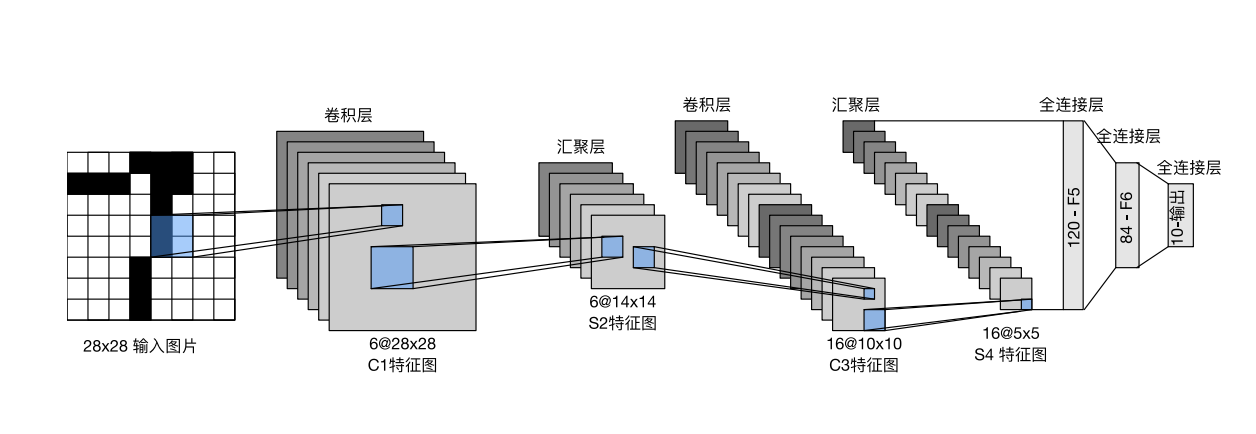

In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [5]:
# 我们可以按照上图的结构复现一下这个卷积神经网络模型
model = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),

    nn.AvgPool2d(kernel_size=2, stride=2),

    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),

    nn.AvgPool2d(2, stride = 2),

    nn.Flatten(),

    nn.Linear(16*5*5, 120), nn.Sigmoid(), 
    
    nn.Linear(120, 84), nn.Sigmoid(),

    nn.Linear(84, 10)
)

# 我们模拟一张 84*84 的黑白图像通过这个神经网络结构

X = torch.rand((1, 1, 28, 28), dtype=torch.float32)

# 可以通过下面的代码查看张量在神经网络中的形状流动
# for layers in model:
    # X = layers(X)
    # print(layers.__class__.__name__,'output shape: \t',X.shape)

实践

In [3]:
# 数据集加载部分
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 加载来自官方的 MNIST 数据集
train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

# 封装为 DataLoader 以便训练时调用
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# 一段简单的加载数据集进行训练并测试的代码 在 cpu 上运行需约 2 min
iters = 10

criterion = nn.CrossEntropyLoss()

model.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for iter in range(iters):
    for i, (images, labels) in enumerate(train_loader):

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
print("finished")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'acc: {100 * correct / total:.2f}%')

finished
测试集准确率: 89.82%


深度卷积神经网络 (AlexNet)

In [12]:
# 一个 AlexNet 结构，与经典的卷积神经网络不同，其利用 ReLU 作为激活函数
net = nn.Sequential(

    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),

    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),

    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),

    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),

    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),

    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),

    nn.Linear(6400, 4096), nn.ReLU(),

    nn.Dropout(p=0.5),

    nn.Linear(4096, 4096), nn.ReLU(),

    nn.Dropout(p=0.5),

    nn.Linear(4096, 10)
)
# AlexNet 的神经元数更多，结构也更深更复杂，下面我们尝试模拟一个 224*224 的灰度图查看其张量的流动

X = torch.randn(1, 1, 224, 224)

# for layers in net:
#     X = layers(X)
#     print(layers.__class__.__name__,'output shape:\t',X.shape)

VGG 网络

In [ ]:
# VGG 块
def vgg_block(num_convs, in_channels, out_channels):

    layers = []

    for _ in range(num_convs):

        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))

        layers.append(nn.ReLU())
        in_channels = out_channels

    layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

    return nn.Sequential(*layers)
# VGG 块结构是若干卷积层和一个池化层，若干个 VGG 块组成 VGG 网络

In [ ]:
conv_arch = ((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))

def vgg(conv_arch):
    conv_blks = []
    in_channels = 1

    # 神经网络中的若干个 VGG 模块
    for (num_convs, out_channels) in conv_arch: 

        conv_blks.append(vgg_block(num_convs, in_channels, out_channels))

        in_channels = out_channels
    
    # VGG 中的线性层结构
    return nn.Sequential(
        *conv_blks, nn.Flatten(),

        nn.Linear(out_channels * 7 * 7, 4096), nn.ReLU(), nn.Dropout(0.5),

        nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5),

        nn.Linear(4096, 10)
    )

NiN 网络

In [9]:
# LeNet、AlexNet和VGG都有一个共同的设计模式：通过一系列的卷积层与汇聚层来提取空间结构特征；然后通过全连接层对特征进行处理。

# NiN块以一个普通卷积层开始，后面是两个 1*1 的卷积层。这两个1*1 卷积层充当带有ReLU激活函数的逐像素全连接层

def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),

        nn.ReLU(),

        nn.Conv2d(out_channels, out_channels, kernel_size = 1), nn.ReLU(),

        nn.Conv2d(out_channels, out_channels, kernel_size = 1), nn.ReLU()
    )

# 一个 NiN 块主要就是这三部分，一个卷积层，两个充当全连接层的、核大小为 1 的卷积层

In [ ]:
# NiN 神经网络模型，常由多个 NiN 块组成
net = nn.Sequential(

    nin_block(1, 96, kernel_size=11, strides=4, padding=0),

    nn.MaxPool2d(3, stride=2),

    nin_block(96, 256, kernel_size=5, strides=1, padding=2),

    nn.MaxPool2d(3, stride=2),

    nin_block(256, 384, kernel_size=3, strides=1, padding=1),

    nn.MaxPool2d(3, stride=2),

    nn.Dropout(0.5),

    nin_block(384, 10, kernel_size=3, strides=1, padding=1),

    nn.AdaptiveAvgPool2d((1, 1)), # 自适应池化层，卷积核的大小可变，不论输入的 h,w ，都输出一个固定大小的张量

    nn.Flatten()
)

X = torch.rand(size=(1, 1, 224, 224))
# for layer in net:
#     X = layer(X)
#     print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


Inception 块

In [15]:
# inception 块是一种含并行连接的卷积块，Inception块由四条并行路径组成

class Inception(nn.Module):
    # c1~c4 是每条路径的输出通道数
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs): # 输入 [batch, in_channels, *, *]
        super(Inception, self).__init__(**kwargs)

        # route 1，单 1*1 卷积层
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1) # [batch, c1, *, *]

        # route 2，1*1 卷积层后接 3*3 卷积层
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1) # [batch, c2[1], *, *]

        # route 3，1*1 卷积层后接 5*5 卷积层
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2) # [batch, c3[1], *, *]

        # route 4，3*3 池化层后接 1*1 卷积层
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1) # [batch, c4, *, *]

    # 四个路径同步传播
    def forward(self, X):
        p1 = nn.ReLU(self.p1_1(X))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))

        return torch.cat((p1, p2, p3, p4), dim=1) # 在四个维度依次拼接起来 [batch, c1+c2[1]+c3[1]+c4, *, *]

model = Inception(3, 2, (6, 12), (6, 12), 2)

# print(model)

残差网络 (ResNet)

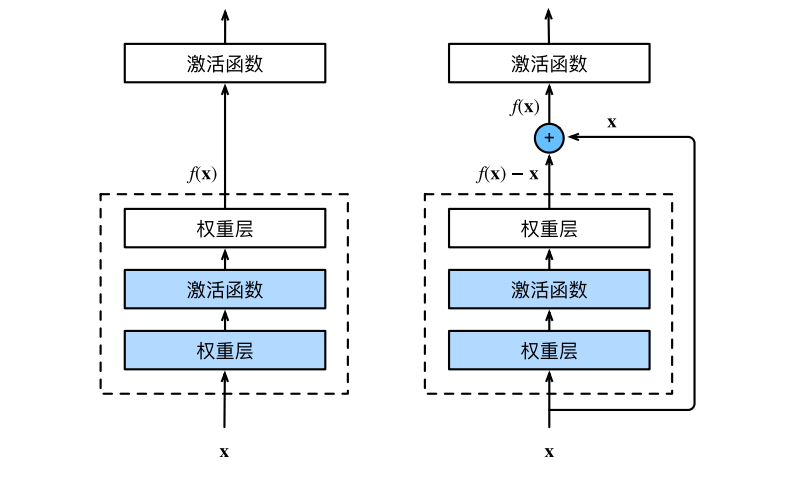

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
class Residual(nn.Module):
    def __init__(self, input_channels, num_channels, use_1x1_conv=False, strides=1):
        super().__init__()

        self.conv1 = nn.Conv2d(input_channels, num_channels, kernel_size = 3, padding = 1, stride = strides)

        self.conv2 = nn.Conv2d(input_channels, num_channels, kernel_size = 3, padding = 1)

        if use_1x1_conv: # 是否带一个 1*1 卷积层，见下图
            self.conv3 = nn.Conv2d(input_channels, num_channels, kernel_size = 1, stride = strides)
        else:
            self.conv3 = None
        
        self.bn1, self.bn2 = nn.BatchNorm2d(num_channels), nn.BatchNorm2d(num_channels)

    def forward(self, X):

        Y = F.relu(self.bn1(self.conv1(X)))

        Y = self.bn2(self.conv2(Y))

        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)


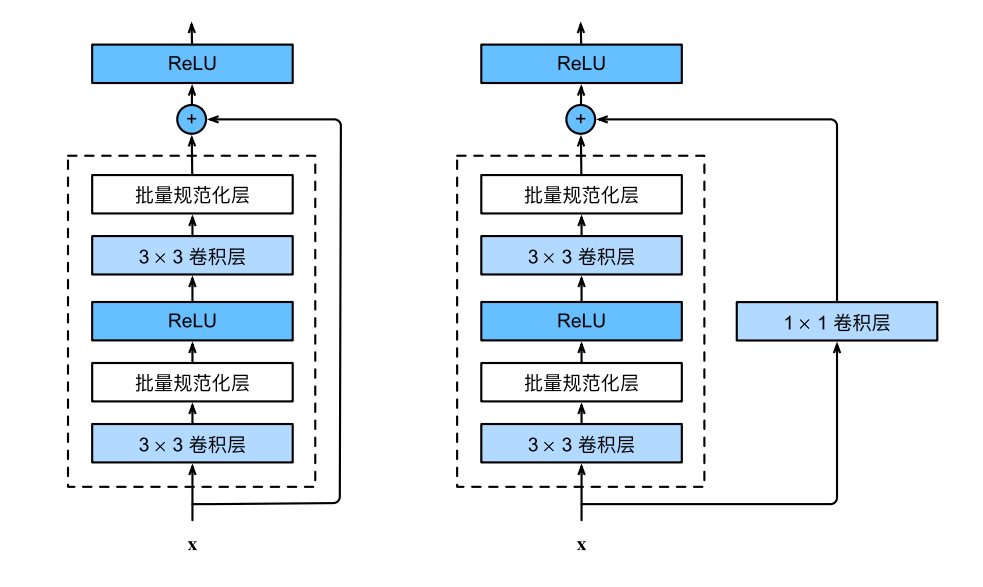

In [ ]:
# ResNet 就是这样结构的块相拼接组成的

b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

def resnet_block(input_channels, num_channels, num_residuals, first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels, use_1x1_conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

net = nn.Sequential(b1, b2, b3, b4, b5,
nn.AdaptiveAvgPool2d((1,1)),
nn.Flatten(), nn.Linear(512, 10))

稠密连接网络 DenseNet

In [ ]:
# 残差神经网络利用了一阶泰勒展开的思想，稠密连接网络将这种思想扩展到高阶

#### 9. 循环神经网络及衍生算法

基础RNN模型

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# 定义一个基础的 rnn 
input_size, hidden_size, num_layers = 10, 20, 1 #num_layers 是 rnn 的层数 
seq_len = 5        # rnn 的序列长度
batch_size = 3 
class BasicRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super(BasicRNN, self).__init__()

        self.hidden_size = hidden_size

        self.num_layers = num_layers

        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True  # batch_first 可以把 batch 维度提前，[batch, seq, feature]，否则在第二个位置
        )
        
    def forward(self, x, hidden): # 额外需要传入一个 hidden 参数，是隐藏层的初始状态
        
        out, hidden = self.rnn(x, hidden)

        return out, hidden

model = BasicRNN(input_size, hidden_size, num_layers) 

input_data = torch.randn(batch_size, seq_len, input_size) # [3, 5, 10]

hidden_init = torch.zeros(num_layers, batch_size, hidden_size) # [1, 3, 20]

output, hidden_final = model(input_data, hidden_init)

门控循环单元(GRU)

In [16]:
# GRU 将隐状态特征分为两个部分，一部分是重置门，一部分是更新门

# 从零实现一个 GRU 模型

class gru(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(gru, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        # 共六个线性层，代表三个门控流，代表重置门、更新门、候选隐状态
        self.linear_hr = nn.Linear(hidden_size, hidden_size, bias=True)
        self.linear_hz = nn.Linear(hidden_size, hidden_size, bias=True)
        self.linear_hh = nn.Linear(hidden_size, hidden_size, bias=True)

        self.linear_xr = nn.Linear(input_size, hidden_size, bias = False)
        self.linear_xz = nn.Linear(input_size, hidden_size, bias = False)
        self.linear_xh = nn.Linear(input_size, hidden_size, bias = False)

    def forward(self, X, h_prev=None): # 在单时间步的前向传播，h_prev 是上回合输出的 H
        # 如果没有输入进来的 H 就先初始化一个零矩阵
        if h_prev is None:
            h_prev = torch.zeros(X.size(0), self.hidden_size, device=X.device, dtype=X.dtype)

        R = F.sigmoid(self.linear_hr(h_prev)+self.linear_xr(X)) # 重置门

        Z = F.sigmoid(self.linear_hz(h_prev)+self.linear_xz(X)) # 更新门

        H = F.tanh(self.linear_xh(X)+self.linear_hh(R*h_prev)) # 候选隐状态

        h_final = Z*h_prev+(1-Z)*H

        return h_final 

# 这是一个 GRU 门控单元的实现方式，实际上我们可以通过一个循环将若干单元拼接起来，返回一个 cat 后的张量

In [17]:
X = torch.randn(2, 5)
model = gru(5, 12)
# print(model(X)) # [2, 12]

长短期记忆网络(LSTM)

In [18]:
# LSTM 有四个分支，分别为遗忘门、输入门、候选记忆元、输出门

class lstm(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(lstm, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        self.linear_hf = nn.Linear(hidden_size, hidden_size, bias=True)
        self.linear_hi = nn.Linear(hidden_size, hidden_size, bias=True)
        self.linear_hc = nn.Linear(hidden_size, hidden_size, bias=True)
        self.linear_ho = nn.Linear(hidden_size, hidden_size, bias=True)

        self.linear_xf = nn.Linear(input_size, hidden_size, bias=False)
        self.linear_xi = nn.Linear(input_size, hidden_size, bias=False)
        self.linear_xc = nn.Linear(input_size, hidden_size, bias=False)
        self.linear_xo = nn.Linear(input_size, hidden_size, bias=False)

    def forward(self, X, h_prev=None, c_prev=None):
        if h_prev is None:
            h_prev = torch.zeros(X.size(0), self.hidden_size, device=X.device, dtype=X.dtype)
        if c_prev is None:
            c_prev = torch.zeros(X.size(0), self.hidden_size, device=X.device, dtype=X.dtype)

        F = F.sigmoid(self.linear_xf(X)+self.linear_hf(h_prev))
        I = F.sigmoid(self.linear_xi(X)+self.linear_hi(h_prev))
        O = F.sigmoid(self.linear_xo(X)+self.linear_ho(h_prev))
        C = F.tanh(self.linear_xc(X)+self.linear_hc(h_prev))

        c_final = I*C+F*c_prev # 计算记忆元

        h_final = O*F.tanh(c_final) # 计算隐状态

        return c_final, h_final

In [19]:
# 不论是 LSTM 还是 GRU 它们都有很多线性层，有时为了简化，我们选择用一个大的线性层训练，之后再分割
class short_lstm(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(lstm, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        # 因为在进行运算之前，这四个流没有本质的区别，故可以用大线性层计算再分割
        self.linear_h = nn.Linear(hidden_size, 4*hidden_size, bias=True)
        self.linear_x = nn.Linear(input_size, 4*hidden_size, bias=False)

    def forward(self, X, h_prev=None, c_prev=None):
        if h_prev is None:
            h_prev = torch.zeros(X.size(0), self.hidden_size, device=X.device, dtype=X.dtype)
        if c_prev is None:
            c_prev = torch.zeros(X.size(0), self.hidden_size, device=X.device, dtype=X.dtype)

        gates = self.linear_x(X)+self.linear_h(h_prev)

        # 将线性层均分成四份
        I, F, C_tilde, O = gates.chunk(4, dim=1)

        c_final = I*C_tilde+F*c_prev # 计算记忆元

        h_final = O*F.tanh(c_final) # 计算隐状态

        return c_final, h_final

# 同理，GRU 也可以做类似的处理，分成三份后进行计算即可

序列到序列学习 (seq2seq)

In [ ]:
# seq2seq 是一种基于 encoder-decoder 模型结构的通用架构，可以用循环神经网络进行填充

# 其将词序列信息先传入一个 embedding 层，将其从 one-hot 向量转到一个连续的空间；

# 再将输出的 embdedding 作为输入，将这个上下文信息输入到循环神经网络中，这是 encoder 的部分

# decoder 需要接收 encoder 的输出，并且输入一个 embedding

# 将这个单元输出的隐状态经 softmax 化为 one-hot 向量，将这个向量输入到 embedding 层，作为第二个单元的输入

In [ ]:
# encoder 的实现
class Seq2SeqEncoder(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0, **kwargs):

        super(Seq2SeqEncoder, self).__init__(**kwargs)

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers, dropout=dropout, batch_first=True)


    def forward(self, X, *args): # [batch, num_steps]

        X = self.embedding(X) # [batch, num_steps, embed_size]
        
        output, state = self.rnn(X) # output [batch, num_steps, num_hiddens]
                                    # state [num_layers, batch, num_hiddens]
        
        return output, state

# **kwargs, *args 是占位符，用于后期设置 device 等

In [ ]:
# 可以用一小段代码观察一下形状流动
encoder = Seq2SeqEncoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)
encoder.eval()
X = torch.zeros((4, 7), dtype=torch.long)
output, state = encoder(X)
# print(output.shape)
# print(state.shape)

torch.Size([4, 7, 16])
torch.Size([2, 4, 16])


In [ ]:
# decoder 的实现

class Seq2SeqDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0, **kwargs):
        super(Seq2SeqDecoder, self).__init__(**kwargs)

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers, dropout=dropout, batch_first = True)
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, *args):
        return enc_outputs[1]
    
    def forward(self, X, state):
        # 将 X 输入 embedding 层
        X = self.embedding(X)
        # 取上一步最后一个 layer 的 state
        context = state[-1] # [batch, num_hiddens]
        context = context.unsqueeze(1) # [batch, 1, num_hiddens]
        context = context.repeat(1, X.shape[1], 1) # 广播到 [batch, num_steps, num_hiddens]
        X_and_context = torch.cat((X, context), dim=2)
        output, state = self.rnn(X_and_context, state)
        output = self.dense(output)

        return output, state        

注意力汇聚

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [4]:
# 为更好计算注意力特征，可以采用 torch 中的批量矩阵乘法

X = torch.ones((2, 1, 4)) 
Y = torch.ones((2, 4, 6))
# print(torch.bmm(X, Y).shape) # torch.bmm 可以保留批量维度 [2, 1, 6]

In [5]:
# Nadaraya‐Watson核回归
class NWRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = nn.functional.softmax(-((queries - keys) * self.w)**2 / 2, dim=1)
        return torch.bmm(self.attention_weights.unsqueeze(1),values.unsqueeze(-1)).reshape(-1)

点积注意力

In [ ]:
# 缩放点积注意力的实现方式

class DotProductAttention(nn.Module):
    def __init__(self, dropout, **kwargs):
        super(self, DotProductAttention).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):

        d = queries.shape[-1]

        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)

        attention_weights = F.softmax(scores, dim = -1)

        return torch.bmm(self.dropout(attention_weights), values)

# Q: [batch, seq_len, dim]
# K: [batch, seq_len, dim]
# V: [batch, seq_len, dim]
# scores: [batch, seq_len, seq_len]
# Attention: [batch, seq_len, dim]

In [11]:
# 可以用一段代码测试一下维度的变化
Q = torch.randn(10, 5, 12)
K = torch.randn(10, 5, 12)
V = torch.randn(10, 5, 24)
Attention = DotProductAttention(0.5)
attention = Attention(Q, K, V)

print(attention.shape)

torch.Size([10, 5, 24])


In [ ]:
# 一般而言，我们读取 token ，计算 Q, K 点积时常常进行掩码操作
# 因为我们要进行匹配度的计算，常常不考虑当前 token 之后的 token，所以一般将 score 的下三角 mask

# 可以人工进行掩码，但需要循环，并不建议这样做
def masked_softmax(scores, valid_lens):
    
    # 生成掩码，有效位置1，无效0
    mask = torch.arange(scores.shape[-1], device=scores.device) < valid_lens.reshape(-1,1,1)
    
    return F.softmax(scores.masked_fill(~mask, -1e9), dim=-1)

In [ ]:
# 神经网络 token 的并行计算虽然提高了效率，但也舍弃了 token 在句中的位置信息

# 我们采用为每个 token 设置位置编码的形式保留位置信息

class PositionEncoding(nn.Module):
    def __init__(self, num_hiddens, dropout, max_len = 1000):

        super(self, PositionEncoding).__init__()

        self.dropout = nn.Dropout(dropout)

        self.P = torch.zeros((1, max_len, num_hiddens))

        X = torch.arange(max_len, dtype=torch.float32).reshape(
        -1, 1) / torch.pow(10000, torch.arange(
        0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

#### 10. Transformer

In [2]:
# 有了上面的基本介绍，可以从头开始构建一个 Transformer 结构了

import torch
import torch.nn as nn
import torch.nn.functional as F
import math 

In [15]:
# 自注意力
class SelfAttention(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()

        self.dropout = nn.Dropout(dropout)

        self.softmax = nn.Softmax(dim = -1) # 对最后一个维度进行 Softmax 

    def forward(self, K, Q, V, mask=None):

        d_k = Q.size(-1) # 最后一个维度的 size 即 dim_v

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k) # 除以 sqrt(d_k) 是为了缩放，让梯度更加稳定

        if mask is not None:
            # 如果提供了 mask 则通过 mask==0 找到需要屏蔽的位置，mask_fill 会把对应值设成 -inf         
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = self.softmax(scores)
        attn = self.dropout(attn)

        out = torch.matmul(attn, V) # 一般来说 K,V 维度是一样的，可以相乘

        return out, attn      

In [4]:
# 多头自注意力机制

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()

        assert d_model % n_heads == 0 # 确保多头分割时能整除维度

        self.d_k = d_model // n_heads
        self.n_heads = n_heads

        # 将输入映射到 Q,K,V
        self.W_q = nn.Linear(d_model, d_model) # Query 的线性映射，维度不需要改变，方便后续拆分
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.fc = nn.Linear(d_model, d_model) # 多头拼接后再映射回原来的 d_model 维度，融合不同头的信息

        self.attention = SelfAttention(dropout) # 使用我们已经定义的自注意力
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)
    
    def forward(self, k, q, v, mask=None):
        batch_size = q.size(0) # 一般来说第一个维度就是 batch_size

        initial_q = q # 先人为记录一下 q，以便残差连接
        
        # Q 的维度 [batch, seq_len, d_model]->[batch, -1, n_heads, d_k]->[batch, n_heads, -1, d_k]
        Q = self.W_q(q).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2) 
        K = self.W_k(k).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2) 
        V = self.W_v(v).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2) 

        # 计算注意力
        out, attn = self.attention(K, Q, V, mask) # attn 为注意力权重 QK^T，out 是加权后的值

        # [batch, n_heads, seq_len, d_v] -> [batch, seq_len, n_heads, d_v]
        # contiguous 让 tensor 在内存中连续存储，避免 view 报错
        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.n_heads*self.d_k) # [batch, seq_len, d_model]

        out = self.fc(out) # 让输入和输出一致，方便残差连接

        out = self.dropout(out)

        return self.norm(out+initial_q), attn # 返回一个输出加输入，本质上是一个残差连接+LayerNorm

In [5]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model) # 保证第二个线性层的输出维度等于第一个线性层的输入维度

        self.dropout = nn.Dropout(dropout) 
        self.norm = nn.LayerNorm(d_model) # 对最后一维进行层归一化

    def forward(self, x):
        # x [batch, seq_len, d_model]
        out = self.fc2(self.dropout(torch.relu(self.fc1(x))))
        return self.norm(out+x) # 残差连接加层归一化

In [6]:
# 一个 encoder 的层结构
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_head, d_ff, dropout=0.1):
        super().__init__()
        # 多头注意力机制，输入的是原序列 src，实现序列内部的信息交互，token 可以看到未来信息
        self.self_attention = MultiHeadAttention(d_model, n_head, dropout)
        # 对每个位置向量做非线性变换
        self.ffn = FeedForward(d_model, d_ff, dropout)

    def forward(self, src, src_mask=None):
        # src 是输入序列 [batch, seq_len, d_model]
        out, _ = self.self_attention(src, src, src, src_mask) # src_mask 可以让模型不关注未来 token

        out = self.ffn(out)

        return out

In [7]:
# 一个 decoder 的层结构
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_head, d_ff, dropout=0.1):
        super().__init__()
        # 带有掩码的多头注意力机制，启动 mask，输入 tgt 即已经生成的前几个 token
        self.self_attention = MultiHeadAttention(d_model, n_head, dropout)
        # 交叉注意力机制，主要和 encoder 做交互，Q 来自 encoder，K,V 来自 decoder
        self.cross_attention = MultiHeadAttention(d_model, n_head, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout)

    def forward(self, tgt, memory, tgt_mask=None, memory_mask=None):
        # tgt 是一个目标序列，memory 是编码器的输出

        out, _ = self.self_attention(tgt, tgt, tgt, tgt_mask) # 目标序列的自注意力
        # 将目标序列和原序列进行交互
        out, _ = self.cross_attention(memory, out, memory, memory_mask)
        out = self.ffn(out)
        return out

In [8]:
# 定义一个位置编码
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        # d_model 是词向量维度，初始化一个 [max_len, d_model] 形状的位置编码矩阵
        pe = torch.zeros(max_len, d_model)
        # [max_len, 1] 方便后续与缩放因子相乘 1e4^{2i/d_model}
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        # div_term，每个维度的缩放因子
        div_term = torch.exp(torch.arange(0, d_model, 2).float()*(-math.log(10000.0)/d_model)) # 间隔为 2 代表 2i

        pe[:, 0::2] = torch.sin(position*div_term)
        pe[:, 1::2] = torch.cos(position*div_term)
        # 增加 batch 维度 [1, max_len, d_model]
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe) 
        # 把 pe 存成 buffer，即虽然在模型里，但是不参与训练，会随着模型保存

    def forward(self, x):
        # x 是embedding，[batch, seq_len, d_model]
        seq_len = x.size(1)
        # 返回一个 embedding + positional_embedding的向量
        return x+self.pe[:, :seq_len, :]


In [9]:
# 完整的 encoder
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout=0.1, max_len=5000):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model) # 词嵌入
        self.pos_encoder = PositionalEncoding(d_model, max_len)

        # 构建编码器的堆叠结构，n_layers个
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.d_model = d_model
    
    def forward(self, src, src_mask=None):
        out = self.embedding(src)*math.sqrt(self.d_model)
        # 经过位置编码层
        out = self.pos_encoder(out)
        # 经过若干 encoder_layer
        for layer in self.layers:
            out = layer(out, src_mask) 

        return out # 返回编码输出 [batch, seq_len, d_model]
        

In [13]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout=0.1, max_len=5000):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        # 经过位置编码
        self.pos_encoder = PositionalEncoding(d_model, max_len)
        # 定义解码器列表
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        # 输出投影层，将 decoder 输出映射到原词汇表的大小
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.d_model = d_model

    def forward(self, tgt, memory, tgt_mask=None, memory_mask=None):
        out = self.embedding(tgt)*math.sqrt(self.d_model)
        out = self.pos_encoder(out)
        # 经过若干 decoder_layer
        for layer in self.layers:
            out = layer(out, memory, tgt_mask, memory_mask) 
        # 将解码器最后一层的隐藏向量映射成 vocab_size
        return self.fc_out(out)

In [11]:
# 构建一个完整的 transformer
class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=512, n_heads=8,
                 num_encoder_layers=6, num_decoder_layers=6,
                 d_ff=2048, dropout=0.1, max_len=5000
    ):
    # src_vocab 原语言词表大小，tgt_vocab 是目标语言词表大小
        super().__init__()
        # encoder 将源语言 token 编码为潜在上下文表示
        self.encoder = Encoder(
            src_vocab, d_model, n_heads, num_encoder_layers, d_ff, dropout, max_len
        )

        # decoder 根据编码器的输出和目标语言的输入生成预测
        self.decoder = Decoder(
            tgt_vocab, d_model, n_heads, num_decoder_layers, d_ff, dropout, max_len
        )

    def forward(self, src, tgt, src_mask=None, tgt_mask=None, memory_mask=None):
        memory = self.encoder(src, src_mask)

        out = self.decoder(tgt, memory, tgt_mask=tgt_mask, memory_mask=memory_mask)

        return out


def generate_mask(size):
    mask = torch.triu(torch.ones(size,size),diagonal=1).bool()
    return mask==0

In [16]:
# 一段验证代码
src_vocab = 10000
tgt_vocab = 10000

# 初始化
model = Transformer(src_vocab, tgt_vocab)
src = torch.randint(0, src_vocab, (32, 10)) # batch=32, src_len=10
tgt = torch.randint(0, src_vocab, (32, 20))

tgt_mask = generate_mask(tgt.size(1)).to(tgt.device)

out = model(src, tgt, src_mask = None, tgt_mask = tgt_mask)

print(out.shape) # batch, tgt_len, tgt_vocab

torch.Size([32, 20, 10000])
